# Notebook 05 - Model Evaluation
## Fake News Detection - NLP Assignment
### W.A. Irusha Madushan (CIT-24-01-0514)
### Evaluating: Random Forest (ML) + CNN (Deep Learning)

In [1]:
import numpy as np
import pandas as pd
import scipy.sparse as sp
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.metrics import (accuracy_score, precision_score, 
                             recall_score, f1_score,
                             confusion_matrix, roc_auc_score, 
                             roc_curve)

import tensorflow as tf
from tensorflow.keras.models import load_model

print("All libraries imported successfully")

All libraries imported successfully


## 1. Loading Models and Features

The trained Random Forest and CNN models are loaded along with 
the test data that was saved in Notebook 03. The same test set 
is used for both models to ensure a fair comparison.

In [2]:
# Load data
X_test_tfidf = sp.load_npz('../models/X_test_tfidf.npz')
X_test_pad = np.load('../models/X_test_pad.npy')
y_test = np.load('../models/y_test.npy')

# Load Random Forest model
with open('../models/rf_final_model.pkl', 'rb') as f:
    rf_model = pickle.load(f)

# Load CNN model
cnn_model = load_model('../models/cnn_final_model.keras')

print("All models and features loaded successfully")
print("Test set size:", len(y_test))
print("Random Forest model loaded:", rf_model)
print("CNN model loaded:", cnn_model.name)

All models and features loaded successfully
Test set size: 14409
Random Forest model loaded: RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=42)
CNN model loaded: sequential_6


## 2. Random Forest Model Evaluation

The Random Forest model is evaluated using five metrics:
- Accuracy: overall percentage of correct predictions
- Precision: out of all articles predicted as fake, how many 
  were actually fake
- Recall: out of all actual fake articles, how many did the 
  model correctly identify
- F1-Score: balanced average of precision and recall
- ROC-AUC: measures how well the model separates fake and 
  real news across all thresholds

In [3]:
# Random Forest predictions
rf_predictions = rf_model.predict(X_test_tfidf)
rf_probabilities = rf_model.predict_proba(X_test_tfidf)[:, 1]

# Calculate metrics
rf_accuracy = accuracy_score(y_test, rf_predictions)
rf_precision = precision_score(y_test, rf_predictions)
rf_recall = recall_score(y_test, rf_predictions)
rf_f1 = f1_score(y_test, rf_predictions)
rf_roc_auc = roc_auc_score(y_test, rf_probabilities)

print("=" * 45)
print("   Random Forest Evaluation Results")
print("=" * 45)
print(f"Accuracy:  {rf_accuracy * 100:.2f}%")
print(f"Precision: {rf_precision * 100:.2f}%")
print(f"Recall:    {rf_recall * 100:.2f}%")
print(f"F1-Score:  {rf_f1 * 100:.2f}%")
print(f"ROC-AUC:   {rf_roc_auc * 100:.2f}%")
print("=" * 45)

   Random Forest Evaluation Results
Accuracy:  95.53%
Precision: 94.89%
Recall:    96.50%
F1-Score:  95.69%
ROC-AUC:   99.28%


## 3. Random Forest Confusion Matrix

A confusion matrix shows the breakdown of correct and incorrect 
predictions in detail. It shows how many articles were correctly 
classified as fake or real, and how many were misclassified.

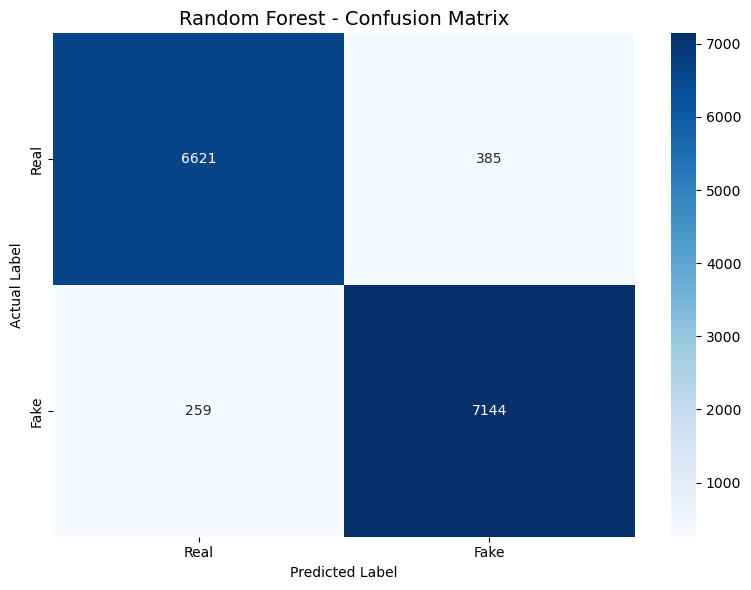

Real predicted as Real: 6621
Real predicted as Fake: 385
Fake predicted as Real: 259
Fake predicted as Fake: 7144


In [4]:
rf_cm = confusion_matrix(y_test, rf_predictions)

plt.figure(figsize=(8, 6))
sns.heatmap(rf_cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Real', 'Fake'],
            yticklabels=['Real', 'Fake'])
plt.title('Random Forest - Confusion Matrix', fontsize=14)
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('../screenshots/rf_confusion_matrix.png', dpi=150)
plt.show()

# Print breakdown
tn, fp, fn, tp = rf_cm.ravel()
print(f"Real predicted as Real: {tn}")
print(f"Real predicted as Fake: {fp}")
print(f"Fake predicted as Real: {fn}")
print(f"Fake predicted as Fake: {tp}")

## 4. Random Forest ROC-AUC Curve

The ROC curve shows how well the model separates fake and real 
news at different classification thresholds. A curve closer to 
the top left corner means better performance. The AUC (Area 
Under Curve) score of 1.0 means perfect classification while 
0.5 means random guessing.

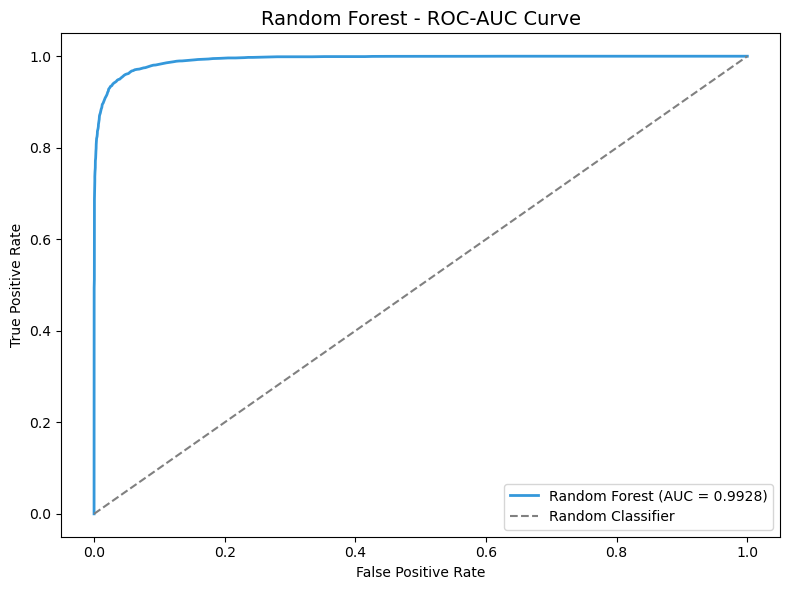

Random Forest ROC-AUC Score: 99.28%


In [5]:
# Random Forest ROC curve
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_probabilities)

plt.figure(figsize=(8, 6))
plt.plot(rf_fpr, rf_tpr, color='#3498db', linewidth=2,
         label=f'Random Forest (AUC = {rf_roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', 
         label='Random Classifier')
plt.title('Random Forest - ROC-AUC Curve', fontsize=14)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.tight_layout()
plt.savefig('../screenshots/rf_roc_curve.png', dpi=150)
plt.show()

print(f"Random Forest ROC-AUC Score: {rf_roc_auc * 100:.2f}%")

## Note - CNN Evaluation Uses Word2Vec Model

The CNN model evaluated below was retrained in Notebook 04 
using Word2Vec pretrained embeddings trained on the WELFake 
dataset. This replaces the earlier Keras Tokenizer approach 
and correctly follows the feature engineering method stated 
in the group assignment proposal.

In [6]:
from tensorflow.keras.models import load_model

# Load CNN model trained with Word2Vec embeddings
cnn_model = load_model('../models/cnn_w2v_final_model.keras')

X_test_pad = np.load('../models/X_test_pad.npy')

print("Word2Vec CNN model loaded successfully")
print("Test set size:", len(y_test))

Word2Vec CNN model loaded successfully
Test set size: 14409


## 5. CNN Model Evaluation

The CNN model trained with Word2Vec embeddings is evaluated 
using the same five metrics used for Random Forest. Using the 
same test set for both models ensures the comparison is fair.

In [7]:
cnn_probabilities = cnn_model.predict(X_test_pad, verbose=0).flatten()
cnn_predictions = (cnn_probabilities >= 0.5).astype(int)

# Calculateing metrics
cnn_accuracy  = accuracy_score(y_test, cnn_predictions)
cnn_precision = precision_score(y_test, cnn_predictions)
cnn_recall    = recall_score(y_test, cnn_predictions)
cnn_f1        = f1_score(y_test, cnn_predictions)
cnn_roc_auc   = roc_auc_score(y_test, cnn_probabilities)

print("=" * 45)
print("   CNN with Word2Vec Evaluation Results")
print("=" * 45)
print(f"Accuracy:  {cnn_accuracy  * 100:.2f}%")
print(f"Precision: {cnn_precision * 100:.2f}%")
print(f"Recall:    {cnn_recall    * 100:.2f}%")
print(f"F1-Score:  {cnn_f1        * 100:.2f}%")
print(f"ROC-AUC:   {cnn_roc_auc   * 100:.2f}%")
print("=" * 45)

   CNN with Word2Vec Evaluation Results
Accuracy:  96.79%
Precision: 95.73%
Recall:    98.14%
F1-Score:  96.92%
ROC-AUC:   99.55%


### CNN Evaluation Results

The CNN model with Word2Vec embeddings achieved the following 
results on the test set of 14,409 articles:

- Accuracy:  96.79%
- Precision: 95.73%
- Recall:    98.14%
- F1-Score:  96.92%
- ROC-AUC:   99.55%

Precision of 95.73% means that out of all articles 
the CNN predicted as fake, 95.73% were actually fake. 
Recall of 98.14% means the model correctly identified 
98.14% of all actual fake articles in the test set. 
The high ROC-AUC score shows the model separates fake and real 
news very effectively across all classification thresholds.

## 6. CNN Confusion Matrix

A confusion matrix shows the exact breakdown of correct and 
incorrect predictions made by the CNN model on the test set.

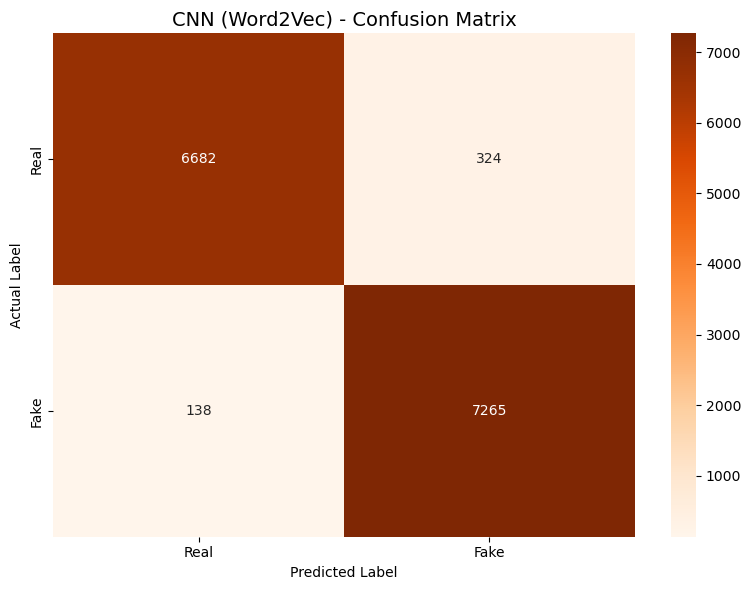

Real predicted as Real: 6682
Real predicted as Fake: 324
Fake predicted as Real: 138
Fake predicted as Fake: 7265


In [8]:
cnn_cm = confusion_matrix(y_test, cnn_predictions)

plt.figure(figsize=(8, 6))
sns.heatmap(cnn_cm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Real', 'Fake'],
            yticklabels=['Real', 'Fake'])
plt.title('CNN (Word2Vec) - Confusion Matrix', fontsize=14)
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('../screenshots/cnn_w2v_confusion_matrix.png', dpi=150)
plt.show()

tn, fp, fn, tp = cnn_cm.ravel()
print(f"Real predicted as Real: {tn}")
print(f"Real predicted as Fake: {fp}")
print(f"Fake predicted as Real: {fn}")
print(f"Fake predicted as Fake: {tp}")

### CNN Confusion Matrix Insight
To get a better sense of where the model occasionally slips up, I looked at the confusion matrix. Out of the 14,409 test articles:
- **6,682** real articles were correctly identified as real.
- **324** real articles were mistakenly flagged as fake.
- **138** fake articles were missed and labeled as real.
- **7,265** fake articles were successfully identified.

When I compare this to the Random Forest model which had 385 false positives and 259 false negatives it is clear that the CNN is more precise. Since the CNN ended up with fewer total misclassifications than the Random Forest, this shows the CNN made fewer total errors on this test set.

## 7. CNN ROC-AUC Curve

The ROC curve for the CNN model shows how well it separates 
fake and real news at different classification thresholds. 
It is plotted alongside the Random Forest ROC curve for 
direct visual comparison.

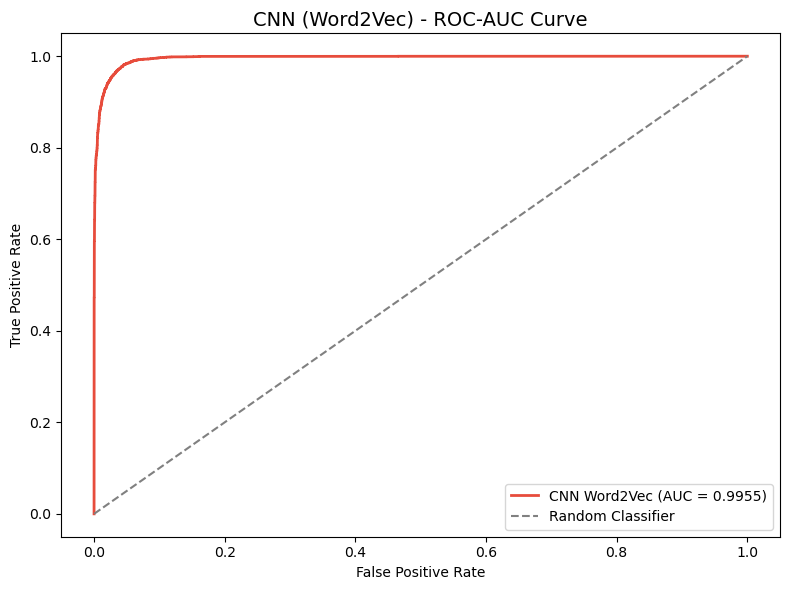

CNN (Word2Vec) ROC-AUC Score: 99.55%


In [9]:
cnn_fpr, cnn_tpr, _ = roc_curve(y_test, cnn_probabilities)

plt.figure(figsize=(8, 6))
plt.plot(cnn_fpr, cnn_tpr, color='#e74c3c', linewidth=2,
         label=f'CNN Word2Vec (AUC = {cnn_roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--',
         label='Random Classifier')
plt.title('CNN (Word2Vec) - ROC-AUC Curve', fontsize=14)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.tight_layout()
plt.savefig('../screenshots/cnn_w2v_roc_curve.png', dpi=150)
plt.show()

print(f"CNN (Word2Vec) ROC-AUC Score: {cnn_roc_auc * 100:.2f}%")

## 8. Random Forest vs CNN Model Comparison

Both models are compared side by side using all five evaluation 
metrics. The same test set of 14,409 articles was used for 
both models to ensure a fair comparison.

In [10]:
import pandas as pd

#comparison table
comparison = {
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC'],
    'Random Forest': [
        f"{rf_accuracy  * 100:.2f}%",
        f"{rf_precision * 100:.2f}%",
        f"{rf_recall    * 100:.2f}%",
        f"{rf_f1        * 100:.2f}%",
        f"{rf_roc_auc   * 100:.2f}%"
    ],
    'CNN (Word2Vec)': [
        f"{cnn_accuracy  * 100:.2f}%",
        f"{cnn_precision * 100:.2f}%",
        f"{cnn_recall    * 100:.2f}%",
        f"{cnn_f1        * 100:.2f}%",
        f"{cnn_roc_auc   * 100:.2f}%"
    ]
}

comparison_df = pd.DataFrame(comparison)
print(comparison_df.to_string(index=False))

   Metric Random Forest CNN (Word2Vec)
 Accuracy        95.53%         96.79%
Precision        94.89%         95.73%
   Recall        96.50%         98.14%
 F1-Score        95.69%         96.92%
  ROC-AUC        99.28%         99.55%


The CNN model with Word2Vec embeddings outperformed the Random Forest model across all five evaluation metrics. The accuracy difference of 1.26% shows a clear advantage for the deep learning approach on this dataset. Both models achieved strong performance on the WELFake dataset. The key difference lies in how each model interprets text: Random Forest relies on a statistical frequency-based approach to word importance, whereas the CNN with Word2Vec learns contextual word meanings and detects local phrase patterns through convolutional filters. This ability to capture semantic relationships and document structure gives the CNN a distinct advantage in understanding the nuanced writing style differences between fake and real news.